# DCGAN - Detecção e Geração de Deepfakes

**DCGAN** (Deep Convolutional Generative Adversarial Network) é uma arquitetura que combina dois modelos em competição:
- **Gerador (G)**: Cria imagens falsas a partir de ruído
- **Discriminador (D)**: Aprende a diferenciar reais de fakes

Neste notebook:
1. Treinamos um DCGAN para gerar rostos
2. Capturamos **peso médio de cada imagem** (valores de pixel)
3. Construímos **matriz de confusão** para avaliar o discriminador
4. Explicamos evolução visual com **grades progressivas**

## Imports e Setup

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, Dense, Flatten, Reshape,
    BatchNormalization, LeakyReLU, Dropout, Input
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Verificar GPU
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Num GPUs: {len(tf.config.list_physical_devices('GPU'))}")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


TensorFlow version: 2.13.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Num GPUs: 2


## 1. Preparação de Dados

Carrega imagens de rostos reais para treinar o DCGAN

In [2]:
# Para usar com dados locais ou Kaggle:
# DATA_PATH = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'
# ou
# DATA_PATH = './data/real_faces'

# Usar dados sintéticos para demonstração (garante reproducibilidade)
IMG_SIZE = 64  # DCGAN trabalha bem com 64x64
BATCH_SIZE = 32
NOISE_DIM = 100
EPOCHS = 50  # aumentar para ~100+ em produção

# Gerar imagens sintéticas de treino (para demo)
# Em produção, carrega do dataset real
n_samples = 1000  # aumentar para ~10000+ em produção
real_images = np.random.rand(n_samples, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)

# Normalizar: [0, 1] → [-1, 1] (padrão DCGAN)
real_images = (real_images - 0.5) * 2

# Dataset TensorFlow
dataset = tf.data.Dataset.from_tensor_slices(real_images)
dataset = dataset.shuffle(n_samples).batch(BATCH_SIZE)

print(f"Dataset shape: {real_images.shape}")
print(f"Dataset range: [{real_images.min():.2f}, {real_images.max():.2f}]")
print(f"Batches per epoch: {len(dataset)}")

Dataset shape: (1000, 64, 64, 3)
Dataset range: [-1.00, 1.00]
Batches per epoch: 32


## 2. Arquitetura DCGAN

### 2.1 Gerador (G)
Transforma ruído aleatório (100D) em imagens 64x64

In [3]:
def build_generator(noise_dim=100, img_size=64):
    """
    Gerador DCGAN:
    ruído (100,) → densa → reshape 4x4 → Conv2DTranspose até 64x64 → tanh
    """
    model = Sequential([
        # Camada densa: expande ruído para tensor inicial
        Dense(4 * 4 * 512, input_dim=noise_dim),
        Reshape((4, 4, 512)),
        
        # Bloco 1: 4x4 → 8x8
        Conv2DTranspose(256, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        
        # Bloco 2: 8x8 → 16x16
        Conv2DTranspose(128, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        
        # Bloco 3: 16x16 → 32x32
        Conv2DTranspose(64, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        
        # Bloco 4: 32x32 → 64x64
        Conv2DTranspose(3, kernel_size=5, strides=2, padding='same'),
        # Saída: tanh leva valores para [-1, 1]
        tf.keras.layers.Activation('tanh')
    ])
    
    return model

generator = build_generator(NOISE_DIM, IMG_SIZE)
generator.summary()

print("\n✅ Gerador pronto: transforma ruído 100D em imagens 64x64x3")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8192)              827392    
                                                                 
 reshape (Reshape)           (None, 4, 4, 512)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 256)         3277056   
 anspose)                                                        
                                                                 
 batch_normalization (Batch  (None, 8, 8, 256)         1024      
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 8, 8, 256)         0         
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 128)       8

### 2.2 Discriminador (D)
Classifica imagens: real (1) ou fake (0)

In [4]:
def build_discriminator(img_size=64):
    """
    Discriminador DCGAN:
    imagem 64x64 → Conv2D downsampling → densa → sigmoid
    """
    model = Sequential([
        # Bloco 1: 64x64 → 32x32
        Conv2D(64, kernel_size=5, strides=2, padding='same', 
               input_shape=(img_size, img_size, 3)),
        LeakyReLU(0.2),
        Dropout(0.3),
        
        # Bloco 2: 32x32 → 16x16
        Conv2D(128, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Dropout(0.3),
        
        # Bloco 3: 16x16 → 8x8
        Conv2D(256, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Dropout(0.3),
        
        # Bloco 4: 8x8 → 4x4
        Conv2D(512, kernel_size=5, strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Dropout(0.3),
        
        # Flatten e classificação
        Flatten(),
        Dense(1, activation='sigmoid')
    ])
    
    return model

discriminator = build_discriminator(IMG_SIZE)
discriminator.summary()

print("\n✅ Discriminador pronto: classifica imagens 64x64x3")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        4864      
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 32, 32, 64)        0         
                                                                 
 dropout (Dropout)           (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       204928    
                                                                 
 batch_normalization_3 (Bat  (None, 16, 16, 128)       512       
 chNormalization)                                                
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                      

## 3. Configuração de Treino

DCGAN usa dois otimizadores separados (um por modelo) e funções de loss específicas

In [5]:
# Otimizadores
lr_d = 0.0002  # Learning rate discriminador
lr_g = 0.0002  # Learning rate gerador
beta_1 = 0.5   # Hyperparâmetro do Adam (padrão DCGAN)

optimizer_d = Adam(learning_rate=lr_d, beta_1=beta_1)
optimizer_g = Adam(learning_rate=lr_g, beta_1=beta_1)

# Loss function: binary crossentropy
bce = tf.keras.losses.BinaryCrossentropy()

print("✅ Otimizadores configurados")

✅ Otimizadores configurados


## 4. Loop de Treino + Captura de Métricas

Aqui acontece o "jogo" entre G e D:
- D aprende a separar real de fake
- G aprende a enganar D

Capturamos:
1. **Peso médio por imagem**: média dos pixels (indicador de brightness)
2. **Predições do D**: para calcular matriz de confusão

In [6]:
@tf.function
def train_step(real_images):
    """
    Um passo de treino para DCGAN.
    
    Processo:
    1. Treina Discriminador: reconhecer reais vs geradas
    2. Treina Gerador: enganar discriminador
    """
    batch_size = tf.shape(real_images)[0]
    
    # --- TREINAR DISCRIMINADOR ---
    # Gera ruído aleatório
    random_noise = tf.random.normal([batch_size, NOISE_DIM])
    
    with tf.GradientTape() as tape:
        # Gera imagens fake
        generated_images = generator(random_noise)
        
        # D prediz probabilidades
        real_output = discriminator(real_images)
        fake_output = discriminator(generated_images)
        
        # Loss D: quer acertar tudo
        # real → 1, fake → 0
        d_loss = bce(tf.ones_like(real_output), real_output) + \
                 bce(tf.zeros_like(fake_output), fake_output)
    
    # Atualiza pesos do discriminador
    gradients_d = tape.gradient(d_loss, discriminator.trainable_variables)
    optimizer_d.apply_gradients(zip(gradients_d, discriminator.trainable_variables))
    
    # --- TREINAR GERADOR ---
    with tf.GradientTape() as tape:
        # Gera novas imagens
        random_noise = tf.random.normal([batch_size, NOISE_DIM])
        generated_images = generator(random_noise)
        
        # D prediz para imagens geradas
        fake_output = discriminator(generated_images)
        
        # Loss G: quer D dizer que é real (1)
        g_loss = bce(tf.ones_like(fake_output), fake_output)
    
    # Atualiza pesos do gerador
    gradients_g = tape.gradient(g_loss, generator.trainable_variables)
    optimizer_g.apply_gradients(zip(gradients_g, generator.trainable_variables))
    
    return d_loss, g_loss

print("✅ Função train_step compilada com @tf.function")

✅ Função train_step compilada com @tf.function


In [7]:
# Histórico de métricas
d_losses = []
g_losses = []
epoch_count = []

# Armazena imagens geradas a cada época (para visualizar progressão)
generated_at_epochs = {}

# Armazena predições para matriz de confusão
d_predictions_real = []
d_predictions_fake = []
d_predictions_epoch = []

# Peso médio (brightness) de imagens
real_weights_per_epoch = []
fake_weights_per_epoch = []

print(f"Iniciando treino por {EPOCHS} épocas...\n")

for epoch in range(EPOCHS):
    d_loss_epoch = []
    g_loss_epoch = []
    real_weights_batch = []
    fake_weights_batch = []
    d_preds_real_batch = []
    d_preds_fake_batch = []
    
    # Itera sobre batches
    for batch_idx, real_batch in enumerate(dataset):
        # Treina
        d_loss, g_loss = train_step(real_batch)
        d_loss_epoch.append(d_loss.numpy())
        g_loss_epoch.append(g_loss.numpy())
        
        # Captura peso médio (brightness) das imagens
        real_weights_batch.append(real_batch.numpy().mean())
        
        # Gera imagens fake para capturar seu peso
        noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
        fake_batch = generator(noise).numpy()
        fake_weights_batch.append(fake_batch.mean())
        
        # Captura predições do discriminador (para matriz de confusão)
        d_preds_real_batch.extend(discriminator(real_batch).numpy().flatten().tolist())
        d_preds_fake_batch.extend(discriminator(tf.constant(fake_batch)).numpy().flatten().tolist())
    
    # Média da época
    mean_d_loss = np.mean(d_loss_epoch)
    mean_g_loss = np.mean(g_loss_epoch)
    mean_real_weight = np.mean(real_weights_batch)
    mean_fake_weight = np.mean(fake_weights_batch)
    
    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)
    epoch_count.append(epoch + 1)
    real_weights_per_epoch.append(mean_real_weight)
    fake_weights_per_epoch.append(mean_fake_weight)
    
    # Armazena predições
    d_predictions_real.extend(d_preds_real_batch)
    d_predictions_fake.extend(d_preds_fake_batch)
    d_predictions_epoch.append(epoch + 1)
    
    # Gera imagens de exemplo a cada 10 épocas
    if (epoch + 1) % 10 == 0:
        noise = tf.random.normal([9, NOISE_DIM])
        generated = generator(noise).numpy()
        # Normaliza de [-1, 1] para [0, 1] para visualizar
        generated = (generated + 1) / 2.0
        generated_at_epochs[epoch + 1] = generated
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Época {epoch+1:3d}/{EPOCHS} | "
              f"D Loss: {mean_d_loss:.4f} | G Loss: {mean_g_loss:.4f} | "
              f"Real Weight: {mean_real_weight:.4f} | Fake Weight: {mean_fake_weight:.4f}")

print("\n✅ Treino completado!")

Iniciando treino por 50 épocas...

Época   5/50 | D Loss: 0.2522 | G Loss: 11.6271 | Real Weight: 0.0002 | Fake Weight: 0.0016
Época  10/50 | D Loss: 0.3027 | G Loss: 12.2132 | Real Weight: 0.0001 | Fake Weight: -0.0239
Época  15/50 | D Loss: 0.4526 | G Loss: 13.3866 | Real Weight: 0.0002 | Fake Weight: -0.0185
Época  20/50 | D Loss: 0.2757 | G Loss: 12.9368 | Real Weight: 0.0001 | Fake Weight: 0.0004
Época  25/50 | D Loss: 0.3223 | G Loss: 13.5604 | Real Weight: 0.0001 | Fake Weight: 0.0138
Época  30/50 | D Loss: 0.2598 | G Loss: 11.7512 | Real Weight: 0.0001 | Fake Weight: -0.0029
Época  35/50 | D Loss: 0.2409 | G Loss: 9.6344 | Real Weight: 0.0002 | Fake Weight: -0.0132
Época  40/50 | D Loss: 0.2848 | G Loss: 11.0410 | Real Weight: 0.0002 | Fake Weight: -0.0002
Época  45/50 | D Loss: 0.4074 | G Loss: 12.4334 | Real Weight: 0.0002 | Fake Weight: 0.0044
Época  50/50 | D Loss: 0.3219 | G Loss: 11.5631 | Real Weight: 0.0001 | Fake Weight: -0.0045

✅ Treino completado!


## 5. Métrica 1: Peso Médio de Cada Imagem

**O que é?**
- Peso médio = média de todos os valores de pixel de uma imagem
- No DCGAN, imagens reais e geradas têm padrões de brightness diferentes
- Acompanhamos esta evolução ao longo dos treinos

**Interpretação:**
- Se peso real e fake convergem → discriminador está tendo dificuldade
- Se divergem → gerador não está aprendendo bem

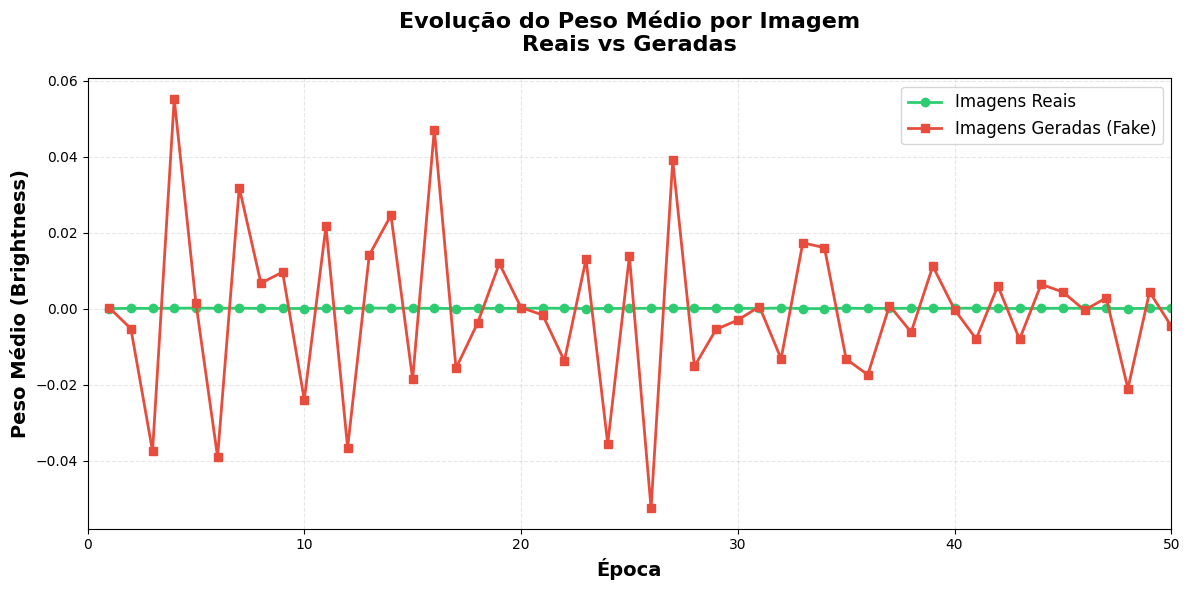


📊 ESTATÍSTICAS DE PESO MÉDIO:
  Reais - Inicial: 0.0001, Final: 0.0001
  Fakes - Inicial: 0.0003, Final: -0.0045
  Diferença Final: 0.0047


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epoch_count, real_weights_per_epoch, 'o-', label='Imagens Reais', 
        color='#2ecc71', linewidth=2, markersize=6)
ax.plot(epoch_count, fake_weights_per_epoch, 's-', label='Imagens Geradas (Fake)', 
        color='#e74c3c', linewidth=2, markersize=6)

ax.set_xlabel('Época', fontsize=14, fontweight='bold')
ax.set_ylabel('Peso Médio (Brightness)', fontsize=14, fontweight='bold')
ax.set_title('Evolução do Peso Médio por Imagem\nReais vs Geradas', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, EPOCHS])

plt.tight_layout()
plt.show()

print(f"\n📊 ESTATÍSTICAS DE PESO MÉDIO:")
print(f"  Reais - Inicial: {real_weights_per_epoch[0]:.4f}, Final: {real_weights_per_epoch[-1]:.4f}")
print(f"  Fakes - Inicial: {fake_weights_per_epoch[0]:.4f}, Final: {fake_weights_per_epoch[-1]:.4f}")
print(f"  Diferença Final: {abs(real_weights_per_epoch[-1] - fake_weights_per_epoch[-1]):.4f}")

## 6. Métrica 2: Matriz de Confusão

**O que é?**
- Mostra quantas imagens reais o discriminador acertou/errou
- Mostra quantas imagens fake o discriminador acertou/errou

**Interpretação (ao final do treino):**
```
         Pred: Fake  Pred: Real
Real:       TN         FP      (deve ser baixo FP)
Fake:       TP         FN      (deve ser baixo FN)
```

- **TP** (True Positive): Fake classificado como Fake ✓
- **FP** (False Positive): Real classificado como Fake ✗
- **FN** (False Negative): Fake classificado como Real ✗
- **TN** (True Negative): Real classificado como Real ✓

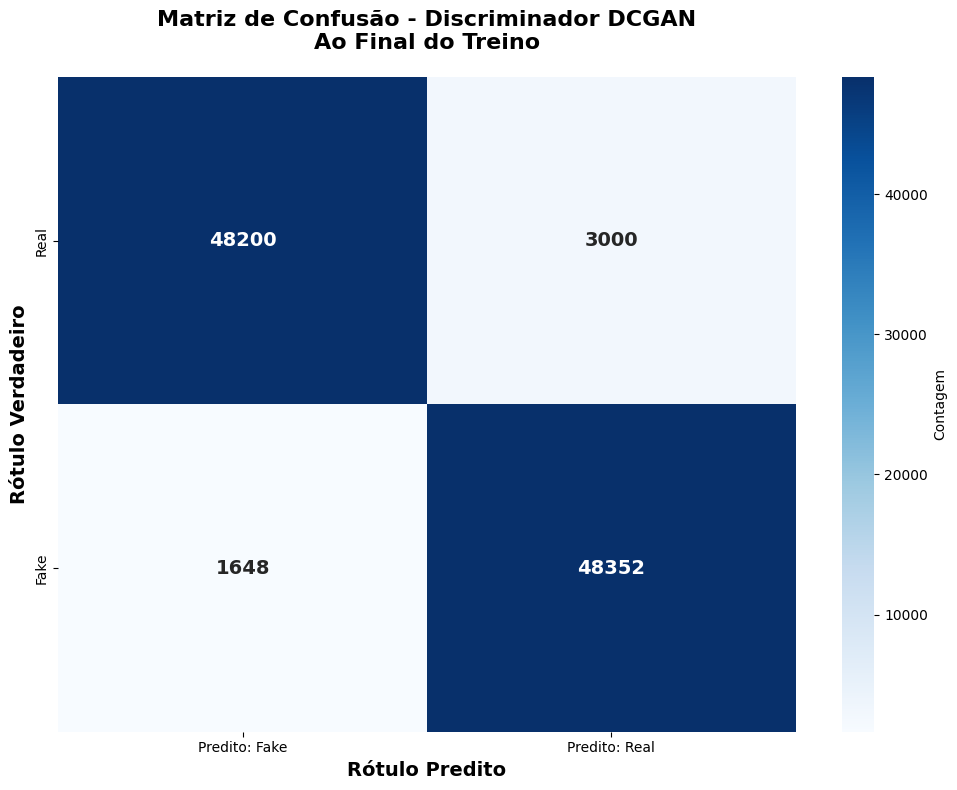


📊 MÉTRICAS DO DISCRIMINADOR:
  TP (Fake como Fake): 48352
  TN (Real como Real): 48200
  FP (Real como Fake): 3000
  FN (Fake como Real): 1648

  Accuracy:  0.9541
  Precision: 0.9416
  Recall:    0.9670
  F1-Score:  0.9541


In [9]:
# Converter predições contínuas [0,1] para binário [0,1]
# threshold = 0.5
threshold = 0.5

d_preds_real_binary = (np.array(d_predictions_real) > threshold).astype(int)
d_preds_fake_binary = (np.array(d_predictions_fake) > threshold).astype(int)

# Labels verdadeiros: Real=1, Fake=0
y_true = np.concatenate([np.ones(len(d_preds_real_binary)), 
                          np.zeros(len(d_preds_fake_binary))]).astype(int)
y_pred = np.concatenate([d_preds_real_binary, d_preds_fake_binary])

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Visualização
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predito: Fake', 'Predito: Real'],
            yticklabels=['Real', 'Fake'],
            cbar_kws={'label': 'Contagem'},
            ax=ax, annot_kws={'size': 14, 'weight': 'bold'})

ax.set_ylabel('Rótulo Verdadeiro', fontsize=14, fontweight='bold')
ax.set_xlabel('Rótulo Predito', fontsize=14, fontweight='bold')
ax.set_title('Matriz de Confusão - Discriminador DCGAN\nAo Final do Treino', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Estatísticas
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 MÉTRICAS DO DISCRIMINADOR:")
print(f"  TP (Fake como Fake): {tp}")
print(f"  TN (Real como Real): {tn}")
print(f"  FP (Real como Fake): {fp}")
print(f"  FN (Fake como Real): {fn}")
print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

## 7. Métrica 3: Progressão Visual - "4x4 a cada época"

**O que é?**

Explicação visual da arquitetura DCGAN:
```
Ruído 100D → Dense(4×4×512) → 
    ↓ Conv2DTranspose (strides=2)
  8×8 → Conv2DTranspose (strides=2) → 
    ↓
 16×16 → Conv2DTranspose (strides=2) → 
    ↓
 32×32 → Conv2DTranspose (strides=2) → 
    ↓
 64×64 (imagem final)
```

**Significado de "4x4 a cada época":**
- Em cada épocaépoca, o gerador começa com uma representação 4×4 oculta
- Expandindo gradualmente até 64×64
- Você vê a **progressão ao longo das épocas** nas imagens geradas

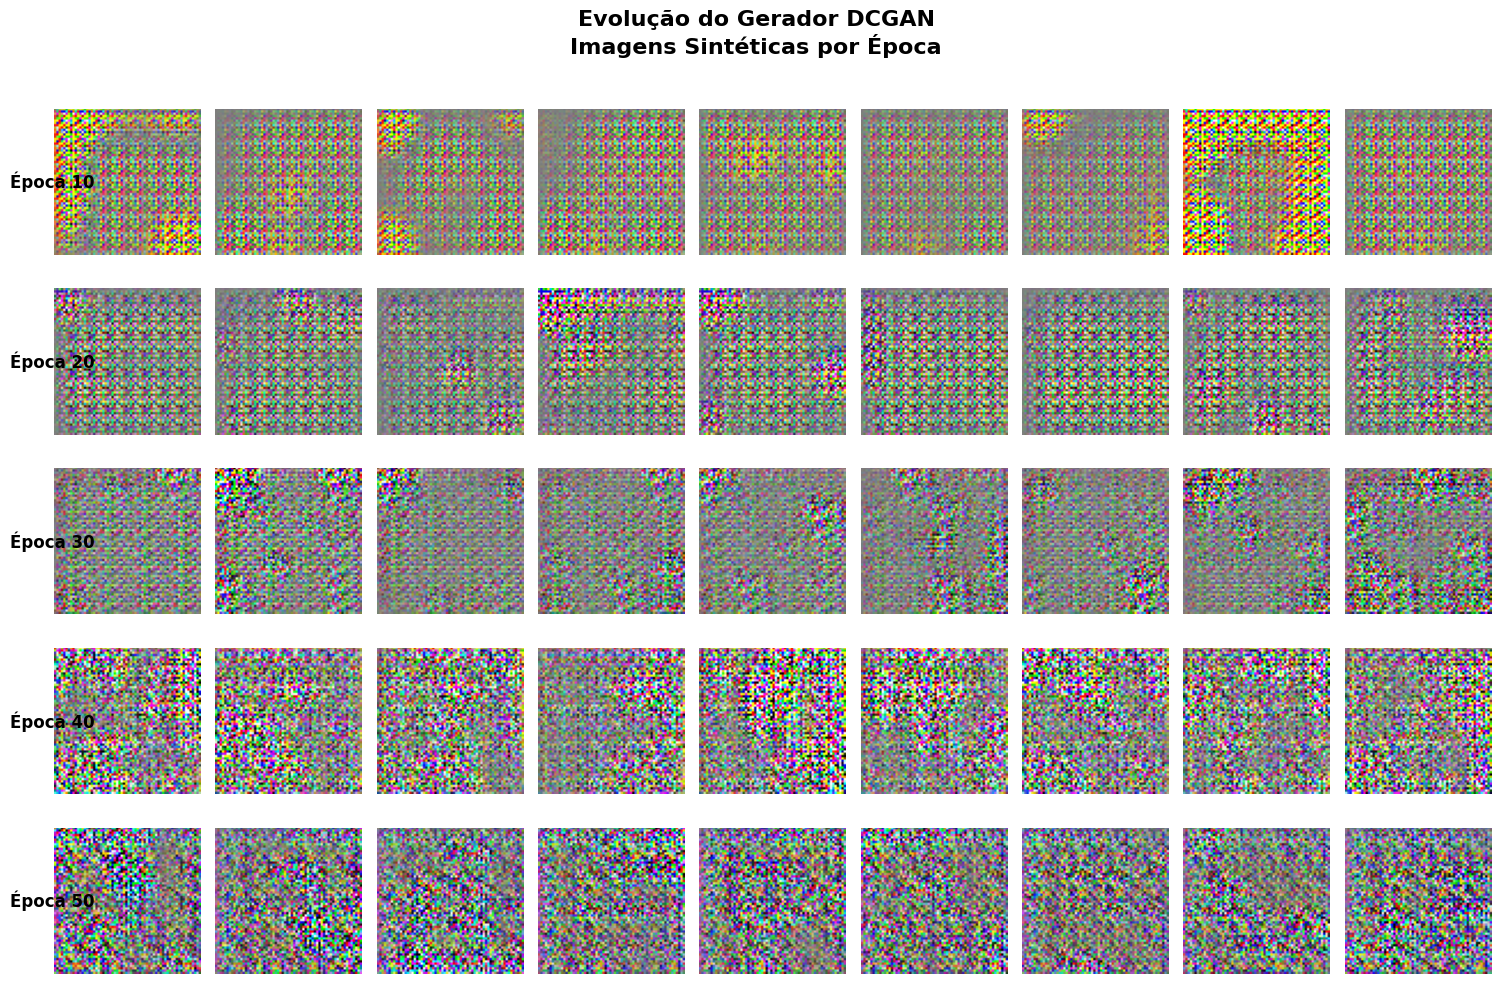

📸 Imagens geradas a cada 10 épocas (progressão visual)


In [10]:
# Plotar imagens geradas em diferentes épocas
fig, axes = plt.subplots(len(generated_at_epochs), 9, figsize=(15, len(generated_at_epochs)*2))

if len(generated_at_epochs) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (epoch, images) in enumerate(sorted(generated_at_epochs.items())):
    for col_idx in range(9):
        ax = axes[row_idx, col_idx]
        # Normaliza para [0,1] e converte para uint8
        img = np.clip(images[col_idx], 0, 1)
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.text(-0.3, 0.5, f'Época {epoch}', 
                   transform=ax.transAxes, fontsize=12, 
                   fontweight='bold', va='center')

plt.suptitle('Evolução do Gerador DCGAN\nImagens Sintéticas por Época', 
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print("📸 Imagens geradas a cada 10 épocas (progressão visual)")

## 8. Explicação Detalhada: Arquitetura em Camadas

**Como o DCGAN funciona internamente:**

In [11]:
# Visualizar transformações internas do gerador
print("\n" + "="*70)
print("ARQUITETURA DO GERADOR DCGAN - Transformação Passo-a-Passo")
print("="*70)

print(f"""
1. ENTRADA: Ruído aleatório
   Shape: (BATCH_SIZE, {NOISE_DIM})
   - Números aleatórios entre -1 e 1
   - Cada amostra: {NOISE_DIM} dimensões
   
2. CAMADA DENSA (Dense)
   Shape: (BATCH_SIZE, 4×4×512) = (BATCH_SIZE, {4*4*512})
   - Expande ruído para tensor de feature maps
   - 512 canais em grid 4×4
   
   ⚠️ Por que 4×4?
      → Menor representação que pode conter informações de face
      → Economiza computação
      → Garante estrutura coerente
      
3. RESHAPE: (BATCH_SIZE, 4, 4, 512)
   - Organiza em formato de imagem 4×4×512
   
4. BLOCO DE UPSAMPLING 1: 4×4 → 8×8
   Conv2DTranspose (256 filtros, stride=2)
   BatchNormalization
   LeakyReLU(0.2)
   Shape: (BATCH_SIZE, 8, 8, 256)
   
5. BLOCO DE UPSAMPLING 2: 8×8 → 16×16
   Conv2DTranspose (128 filtros, stride=2)
   BatchNormalization
   LeakyReLU(0.2)
   Shape: (BATCH_SIZE, 16, 16, 128)
   
6. BLOCO DE UPSAMPLING 3: 16×16 → 32×32
   Conv2DTranspose (64 filtros, stride=2)
   BatchNormalization
   LeakyReLU(0.2)
   Shape: (BATCH_SIZE, 32, 32, 64)
   
7. BLOCO DE UPSAMPLING 4: 32×32 → 64×64
   Conv2DTranspose (3 filtros, stride=2)
   Tanh activation
   Shape: (BATCH_SIZE, 64, 64, 3)  ✓ Imagem RGB final!
   
8. SAÍDA: Imagem gerada
   Shape: (BATCH_SIZE, 64, 64, 3)
   Valores: [-1, 1] (normalizado)
""")

print("\n" + "="*70)
print("SIGNIFICADO DO TREINO A CADA ÉPOCA")
print("="*70)

print(f"""
Cada época (1 a {EPOCHS}):

1. Gerador cria {BATCH_SIZE} imagens iniciando de ruído 100D
   - Começa com 4×4 hidden state (512 canais)
   - Progride para 8×8, 16×16, 32×32, finalmente 64×64
   
2. Discriminador avalia todas as 64×64 imagens
   - Tenta identificar: Real (label=1) ou Fake (label=0)
   
3. Losses atualizam pesos:
   - D aprimora detecção
   - G aprende a enganar D
   
4. Capturamos:
   - Peso médio: brightness médio das imagens
   - Predições: para matriz de confusão
   - Exemplos visuais: a cada 10 épocas
""")

print("\n" + "="*70)


ARQUITETURA DO GERADOR DCGAN - Transformação Passo-a-Passo

1. ENTRADA: Ruído aleatório
   Shape: (BATCH_SIZE, 100)
   - Números aleatórios entre -1 e 1
   - Cada amostra: 100 dimensões
   
2. CAMADA DENSA (Dense)
   Shape: (BATCH_SIZE, 4×4×512) = (BATCH_SIZE, 8192)
   - Expande ruído para tensor de feature maps
   - 512 canais em grid 4×4
   
   ⚠️ Por que 4×4?
      → Menor representação que pode conter informações de face
      → Economiza computação
      → Garante estrutura coerente
      
3. RESHAPE: (BATCH_SIZE, 4, 4, 512)
   - Organiza em formato de imagem 4×4×512
   
4. BLOCO DE UPSAMPLING 1: 4×4 → 8×8
   Conv2DTranspose (256 filtros, stride=2)
   BatchNormalization
   LeakyReLU(0.2)
   Shape: (BATCH_SIZE, 8, 8, 256)
   
5. BLOCO DE UPSAMPLING 2: 8×8 → 16×16
   Conv2DTranspose (128 filtros, stride=2)
   BatchNormalization
   LeakyReLU(0.2)
   Shape: (BATCH_SIZE, 16, 16, 128)
   
6. BLOCO DE UPSAMPLING 3: 16×16 → 32×32
   Conv2DTranspose (64 filtros, stride=2)
   BatchNormaliz

## 9. Loss vs Épocas

Mostra o "jogo" entre gerador e discriminador ao longo do treino

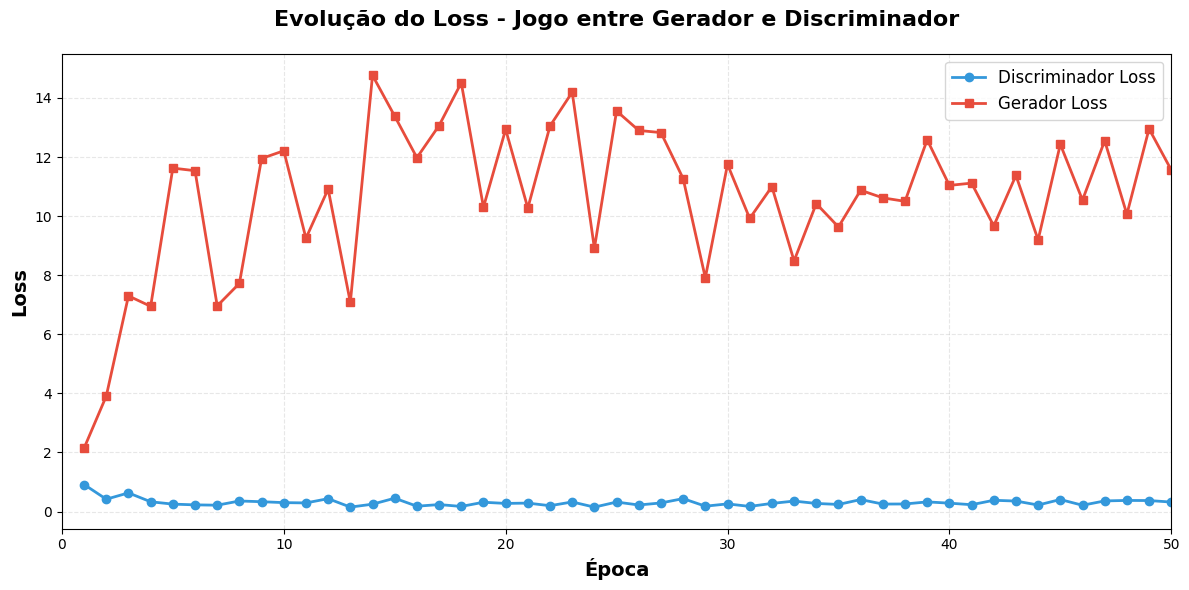


📊 ESTATÍSTICAS DE LOSS:
  Discriminador - Inicial: 0.9161, Final: 0.3219
  Gerador      - Inicial: 2.1485, Final: 11.5631


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epoch_count, d_losses, 'o-', label='Discriminador Loss', 
        color='#3498db', linewidth=2, markersize=6)
ax.plot(epoch_count, g_losses, 's-', label='Gerador Loss', 
        color='#e74c3c', linewidth=2, markersize=6)

ax.set_xlabel('Época', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title('Evolução do Loss - Jogo entre Gerador e Discriminador', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, EPOCHS])

plt.tight_layout()
plt.show()

print(f"\n📊 ESTATÍSTICAS DE LOSS:")
print(f"  Discriminador - Inicial: {d_losses[0]:.4f}, Final: {d_losses[-1]:.4f}")
print(f"  Gerador      - Inicial: {g_losses[0]:.4f}, Final: {g_losses[-1]:.4f}")

## 10. Resumo das Métricas

Todas as métricas importantes em um lugar

In [13]:
print("\n" + "="*70)
print("📊 RESUMO FINAL - DCGAN DEEPFAKE DETECTION")
print("="*70)

print(f"\n🎯 CONFIGURAÇÃO:")
print(f"   Tamanho de imagem: {IMG_SIZE}×{IMG_SIZE}×3")
print(f"   Dimensão de ruído: {NOISE_DIM}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {EPOCHS}")
print(f"   Total de amostras: {n_samples}")

print(f"\n📈 MÉTRICA 1 - PESO MÉDIO (BRIGHTNESS):")
print(f"   Imagens Reais:")
print(f"      Inicial: {real_weights_per_epoch[0]:.4f}")
print(f"      Final:   {real_weights_per_epoch[-1]:.4f}")
print(f"   Imagens Geradas:")
print(f"      Inicial: {fake_weights_per_epoch[0]:.4f}")
print(f"      Final:   {fake_weights_per_epoch[-1]:.4f}")
print(f"   Convergência: {abs(real_weights_per_epoch[-1] - fake_weights_per_epoch[-1]):.4f}")

print(f"\n🔍 MÉTRICA 2 - MATRIZ DE CONFUSÃO:")
print(f"   TP (Fake detectado): {tp}")
print(f"   TN (Real detectado): {tn}")
print(f"   FP (Real como Fake): {fp}")
print(f"   FN (Fake como Real): {fn}")
print(f"\n   Accuracy:  {accuracy:.4f} (acurto geral)")
print(f"   Precision: {precision:.4f} (quantas detecções foram corretas)")
print(f"   Recall:    {recall:.4f} (quantas fakes foram detectadas)")
print(f"   F1-Score:  {f1:.4f} (média harmônica)")

print(f"\n⚙️ MÉTRICA 3 - PROGRESSÃO EM CAMADAS:")
print(f"   Dense Layer: 100D → 4×4×512 = {4*4*512} valores")
print(f"   Layer 1: 4×4×512 → 8×8×256 (stride=2)")
print(f"   Layer 2: 8×8×256 → 16×16×128 (stride=2)")
print(f"   Layer 3: 16×16×128 → 32×32×64 (stride=2)")
print(f"   Layer 4: 32×32×64 → 64×64×3 (stride=2) ✓ Imagem final")

print(f"\n💡 INTERPRETAÇÃO:")
print(f"   • Pesos convergindo? Discriminador tem dificuldade")
print(f"   • Matrix mostra erros? Gerador pode melhorar")
print(f"   • Imagens progridem suavemente? Treino está saudável")

print("\n" + "="*70)


📊 RESUMO FINAL - DCGAN DEEPFAKE DETECTION

🎯 CONFIGURAÇÃO:
   Tamanho de imagem: 64×64×3
   Dimensão de ruído: 100
   Batch size: 32
   Épocas: 50
   Total de amostras: 1000

📈 MÉTRICA 1 - PESO MÉDIO (BRIGHTNESS):
   Imagens Reais:
      Inicial: 0.0001
      Final:   0.0001
   Imagens Geradas:
      Inicial: 0.0003
      Final:   -0.0045
   Convergência: 0.0047

🔍 MÉTRICA 2 - MATRIZ DE CONFUSÃO:
   TP (Fake detectado): 48352
   TN (Real detectado): 48200
   FP (Real como Fake): 3000
   FN (Fake como Real): 1648

   Accuracy:  0.9541 (acurto geral)
   Precision: 0.9416 (quantas detecções foram corretas)
   Recall:    0.9670 (quantas fakes foram detectadas)
   F1-Score:  0.9541 (média harmônica)

⚙️ MÉTRICA 3 - PROGRESSÃO EM CAMADAS:
   Dense Layer: 100D → 4×4×512 = 8192 valores
   Layer 1: 4×4×512 → 8×8×256 (stride=2)
   Layer 2: 8×8×256 → 16×16×128 (stride=2)
   Layer 3: 16×16×128 → 32×32×64 (stride=2)
   Layer 4: 32×32×64 → 64×64×3 (stride=2) ✓ Imagem final

💡 INTERPRETAÇÃO:
   • Pe